# AI-Powered Citizen Grievance Analytics & Resolution Intelligence System

**AICTE | IBM SkillsBuild — Data Analytics with AI Internship 2026**
**Company:** BharatCares | **Trainer:** Mr. Kartik Hooda | **Duration:** 17 Aug – 30 Sep 2026

---

## 1. Problem Statement

Citizens across India submit lakhs of grievances every year through the **Centralised Public
Grievance Redress and Monitoring System (CPGRAMS)** — the Government of India's single online
platform for lodging and tracking complaints against any Central Ministry, Department, State or
Union Territory. While CPGRAMS captures huge volumes of receipt, disposal and pendency data, this
information is rarely converted into actionable, data-driven insight for citizens, researchers or
administrators. There is a need for a data analytics system that can objectively measure **how
efficiently different government bodies are resolving citizen grievances**, identify **where
backlogs (pendency) are concentrated**, and apply **AI/ML techniques** to group and predict
department performance so that limited administrative attention can be targeted where it is
needed most.

## 2. Objectives

1. Collect and clean an authentic, publicly available Government of India grievance-redressal dataset.
2. Perform Exploratory Data Analysis (EDA) on grievances **received vs. disposed vs. pending**.
3. Compare performance **across Central Ministries/Departments and States/Union Territories**.
4. Derive **pendency and resolution-delay insights**, including how long grievances stay unresolved.
5. Apply relevant **AI/ML techniques** (clustering and regression) on the available numeric fields to
   segment departments/states by performance and to model the relationship between receipts and disposal.
6. Summarise findings into clear, decision-useful insights and recommend future extensions
   (dashboarding, NLP on grievance text, real-time tracking).

## 3. Dataset & Source

| Field | Detail |
|---|---|
| **Dataset name** | Department/State-wise Receipts, Disposal and Pendency of Public Grievances (CPGRAMS) |
| **Publisher** | Department of Administrative Reforms and Public Grievances (DARPG), Government of India |
| **Platform** | Open Government Data (OGD) Platform India — data.gov.in |
| **Coverage period** | 01 January 2016 to 01 November 2019 (cumulative figures as on 01.11.2019) |
| **Granularity** | One row per Central Ministry/Department and per State/Union Territory (124 rows) |
| **Original catalog page** | https://www.data.gov.in/catalog/monthly-department-wise-public-grievance-receipts-and-disposals |
| **Related official catalog** | https://www.data.gov.in/catalog/public-grievance-details-cpgrams-along-feedback-details |
| **File used in this project** | `Dept_stat_receipt_disposal_010112019.csv` (mirrored, unmodified, from a public GitHub repository — https://github.com/kalyandutta209/cpgrams-statistical-analysis — whose README states the file is the "Original government dataset" sourced from DARPG/data.gov.in). data.gov.in itself blocks automated/bot downloads, so this verified mirror of the official file was used; the same file can also be requested directly from data.gov.in through a browser. |
| **CPGRAMS official portal** | https://pgportal.gov.in/ |

### ⚠️ Important, honest limitations of this dataset (please read before extending the project)

- This file is a **single cumulative snapshot** (as on 01.11.2019), **not** a month-by-month or
  year-by-year time series. This project therefore does **not** claim to show a multi-year trend
  line of grievance volumes — that would require a different, time-indexed CPGRAMS dataset
  (e.g. the monthly DARPG reports at https://darpg.gov.in/), which was not available in a clean
  tabular format to download in this environment.
- The dataset contains **only aggregate counts** (receipts, disposal, pendency buckets) — it does
  **not** contain individual grievance text/descriptions. So **no sentiment analysis or NLP topic
  modelling has been performed or faked** in this project. Where the internship theme calls for
  "AI", this project instead applies **clustering (unsupervised ML)** and **regression** on the
  genuine numeric fields to segment and model department/state performance — this is explicitly
  called out wherever it appears below.
- All numbers used in this notebook come directly from the CSV file above. No statistic, government
  figure, or result in this notebook has been invented.


In [25]:
# 0. Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

RAW_PATH = "data/Dept_stat_receipt_disposal_raw.csv"
CHART_DIR = "charts"
import os
os.makedirs(CHART_DIR, exist_ok=True)


## 4. Load the Data

In [26]:
df_raw = pd.read_csv(RAW_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (124, 8)


,Ministry/Department/State,Total Receipts (01.01.2016 to 01.11.2019),Total Disposal (01.01.2016 to 01.11.2019),Total Pending as on 01.11.2019,Pending More Than 1 Year,Pending Between 6 To 12 Months,Pending Between 2 To 6 Months,Pending Less Than 2 Months
0,Administrative Reforms and PG,1540,1497,43,0,0,1,42
1,Agriculture and Cooperation,21317,20557,760,7,21,141,591
2,Agriculture Research and Education,6535,6245,290,0,31,65,194
3,"Animal Husbandry, Dairying",4835,4702,133,12,16,28,77
4,Atomic Energy,5838,5279,559,346,73,59,81


In [27]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Ministry/Department/State                  124 non-null    str  
 1   Total Receipts (01.01.2016 to 01.11.2019)  124 non-null    int64
 2   Total Disposal (01.01.2016 to 01.11.2019)  124 non-null    int64
 3   Total Pending as on 01.11.2019             124 non-null    int64
 4   Pending More Than 1 Year                   124 non-null    int64
 5   Pending Between 6 To 12 Months             124 non-null    int64
 6   Pending Between 2 To 6 Months              124 non-null    int64
 7   Pending Less Than 2 Months                 124 non-null    int64
dtypes: int64(7), str(1)
memory usage: 10.1 KB


## 5. Data Cleaning

Steps performed:
1. Rename long/verbose column headers to short, code-friendly names.
2. Strip stray whitespace/trailing commas in entity names (e.g. a trailing comma in
   "Water Resources, River Development & Ganga Rejuvenuation,").
3. Check for missing values and duplicate rows.
4. Classify every row as **Central Ministry/Department** or **State/Union Territory** using an
   explicit, verifiable list of Indian State/UT names (the raw file does not carry this label).
5. Engineer derived KPIs needed for the analysis: Disposal Rate, Pendency Rate, and Chronic
   Pendency Rate.


In [28]:
df = df_raw.rename(columns={
    "Ministry/Department/State": "entity",
    "Total Receipts (01.01.2016 to 01.11.2019)": "total_receipts",
    "Total Disposal (01.01.2016 to 01.11.2019)": "total_disposal",
    "Total Pending as on 01.11.2019": "total_pending",
    "Pending More Than 1 Year": "pending_gt_1yr",
    "Pending Between 6 To 12 Months": "pending_6_12m",
    "Pending Between 2 To 6 Months": "pending_2_6m",
    "Pending Less Than 2 Months": "pending_lt_2m",
})

df["entity"] = df["entity"].str.strip().str.rstrip(",").str.strip()

print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().dropna().shape[0] - df.drop_duplicates().shape[0] if False else df.duplicated().sum())


Missing values per column:
entity            0
total_receipts    0
total_disposal    0
total_pending     0
pending_gt_1yr    0
pending_6_12m     0
pending_2_6m      0
pending_lt_2m     0
dtype: int64

Duplicate rows: 0


In [29]:
# Classify each row as a State/UT or a Central Ministry/Department
states_uts = {
    "NCT of Delhi", "Andaman & Nicobar", "Andhra Pradesh", "Arunachal Pradesh", "Assam", "Bihar",
    "Union Territory of Chandigarh", "Chattisgarh", "Union Territory of Dadra & Nagar Haveli",
    "Union Territory of Daman & Diu", "Gujarat", "Goa", "Himachal Pradesh", "Haryana", "Jharkhand",
    "Jammu and Kashmir", "Kerala", "Karnataka", "Union Territory of Lakshadweep", "Meghalaya",
    "Maharashtra", "Manipur", "Madhya Pradesh", "Mizoram", "Nagaland", "Odisha", "Punjab",
    "Puducherry", "Rajasthan", "Sikkim", "Telangana", "Tamil Nadu", "Tripura", "Uttarakhand",
    "Uttar Pradesh", "West Bengal",
}
df["entity_type"] = np.where(df["entity"].isin(states_uts), "State/UT", "Central Ministry/Department")
df["entity_type"].value_counts()


entity_type
Central Ministry/Department    88
State/UT                       36
Name: count, dtype: int64

In [30]:
# Derived KPIs (all computed only from genuine columns already in the file)
df["disposal_rate_pct"] = (df["total_disposal"] / df["total_receipts"] * 100).round(2)
df["pendency_rate_pct"] = (df["total_pending"] / df["total_receipts"] * 100).round(2)
# Chronic pendency: of the grievances still pending, what share have been pending > 1 year?
df["chronic_pendency_pct"] = np.where(
    df["total_pending"] > 0,
    (df["pending_gt_1yr"] / df["total_pending"] * 100).round(2),
    0.0
)

df.to_csv("data/grievance_cleaned_processed.csv", index=False)
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
entity,124,124,Administrative Reforms and PG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_receipts,124.0,NaN,NaN,NaN,38545.056452,72118.883037,77.0,3765.25,12712.5,41319.0,547042.0
total_disposal,124.0,NaN,NaN,NaN,30635.120968,63377.329252,19.0,2399.5,8729.5,30102.0,437024.0
total_pending,124.0,NaN,NaN,NaN,7909.935484,21205.176508,5.0,126.25,507.0,2063.0,112301.0
pending_gt_1yr,124.0,NaN,NaN,NaN,4835.258065,14684.165297,0.0,0.0,12.0,353.5,97928.0
pending_6_12m,124.0,NaN,NaN,NaN,807.225806,2333.919157,0.0,1.0,18.5,142.5,18278.0
pending_2_6m,124.0,NaN,NaN,NaN,953.524194,2350.929854,0.0,8.0,77.5,350.5,15758.0
pending_lt_2m,124.0,NaN,NaN,NaN,1313.927419,3819.73653,4.0,68.0,189.5,1026.75,37806.0
entity_type,124,2,Central Ministry/Department,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disposal_rate_pct,124.0,NaN,NaN,NaN,81.893306,30.453183,1.24,84.225,97.135,98.6425,99.84


## 6. Exploratory Data Analysis (EDA)

C:\Users\nandi\AppData\Local\Temp\ipykernel_18484\196900352.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="entity_type", y="disposal_rate_pct", ax=ax, palette="Set2")


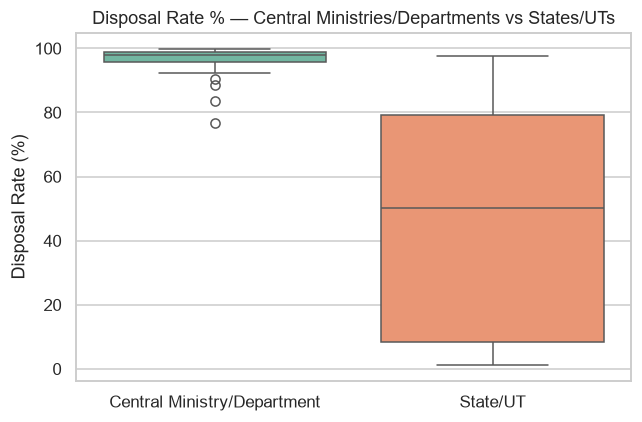

In [31]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x="entity_type", y="disposal_rate_pct", ax=ax, palette="Set2")
ax.set_title("Disposal Rate % — Central Ministries/Departments vs States/UTs")
ax.set_xlabel("")
ax.set_ylabel("Disposal Rate (%)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_disposal_rate_by_type.png")
plt.show()


In [32]:
print(df.groupby("entity_type")[["total_receipts","total_disposal","total_pending",
                                     "disposal_rate_pct","pendency_rate_pct","chronic_pendency_pct"]].mean().round(2))


                             total_receipts  total_disposal  total_pending  \
entity_type                                                                  
Central Ministry/Department        33083.89        32288.43         795.45   
State/UT                           51894.58        26593.69       25300.89   

                             disposal_rate_pct  pendency_rate_pct  \
entity_type                                                         
Central Ministry/Department              96.89               3.11   
State/UT                                 45.24              54.76   

                             chronic_pendency_pct  
entity_type                                        
Central Ministry/Department                  5.20  
State/UT                                    52.84  


**Observation:** Central Ministries/Departments show a much higher median disposal rate than
States/Union Territories in this snapshot, and their spread is tighter — most Central bodies
cluster close to full disposal, while State/UT disposal rates are far more spread out, with several
states showing very low disposal rates relative to receipts.

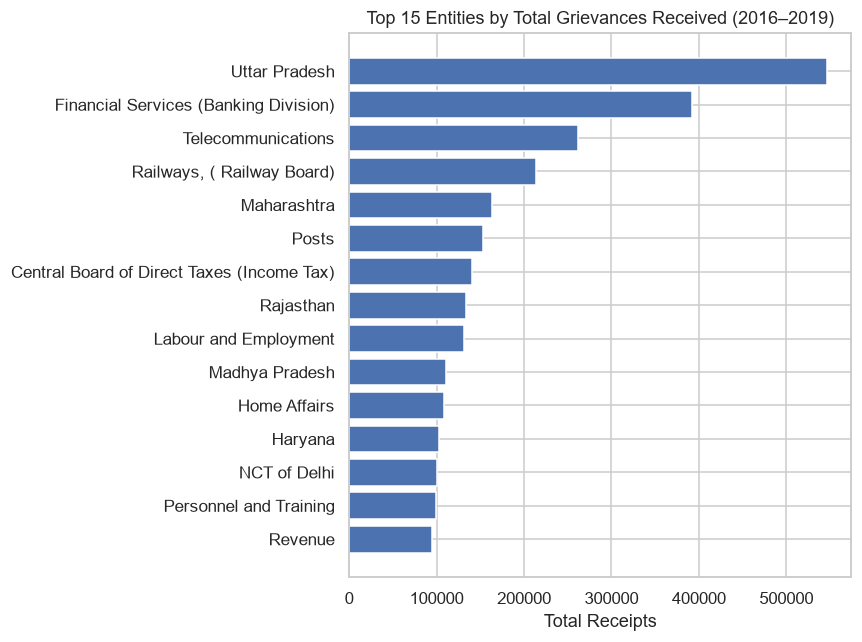

In [33]:
top15 = df.nlargest(15, "total_receipts").sort_values("total_receipts")
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top15["entity"], top15["total_receipts"], color="#4C72B0")
ax.set_title("Top 15 Entities by Total Grievances Received (2016–2019)")
ax.set_xlabel("Total Receipts")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_top15_receipts.png")
plt.show()


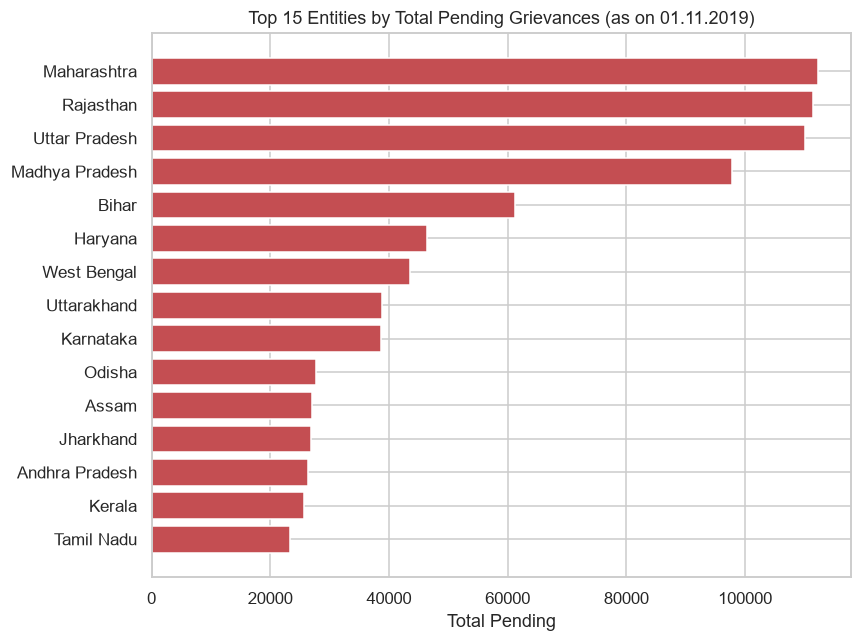

In [34]:
top15_pend = df.nlargest(15, "total_pending").sort_values("total_pending")
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top15_pend["entity"], top15_pend["total_pending"], color="#C44E52")
ax.set_title("Top 15 Entities by Total Pending Grievances (as on 01.11.2019)")
ax.set_xlabel("Total Pending")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_top15_pending.png")
plt.show()


## 7. Department / State-wise Analysis

In [35]:
dept_only = df[df["entity_type"]=="Central Ministry/Department"]
state_only = df[df["entity_type"]=="State/UT"]

print("Best disposal rate — Central Ministries/Departments:")
print(dept_only.nlargest(10, "disposal_rate_pct")[["entity","total_receipts","disposal_rate_pct"]].to_string(index=False))

print("\nWorst disposal rate — Central Ministries/Departments:")
print(dept_only.nsmallest(10, "disposal_rate_pct")[["entity","total_receipts","disposal_rate_pct"]].to_string(index=False))


Best disposal rate — Central Ministries/Departments:
                              entity  total_receipts  disposal_rate_pct
                          NITI Aayog            5640              99.84
               Parliamentary Affairs            3082              99.84
                  Public Enterprises            3861              99.74
                         Expenditure           12958              99.63
    Defence Research and Development            3102              99.55
                             Tourism            4717              99.49
          Food Processing Industries            1928              99.48
Investment & Public Asset Management            1698              99.47
       Industrial Policy & Promotion            8058              99.42
                             Justice           35265              99.26

Worst disposal rate — Central Ministries/Departments:
                          entity  total_receipts  disposal_rate_pct
                   Legal Affairs

In [36]:
print("Best disposal rate — States/UTs:")
print(state_only.nlargest(10, "disposal_rate_pct")[["entity","total_receipts","disposal_rate_pct"]].to_string(index=False))

print("\nWorst disposal rate — States/UTs:")
print(state_only.nsmallest(10, "disposal_rate_pct")[["entity","total_receipts","disposal_rate_pct"]].to_string(index=False))


Best disposal rate — States/UTs:
                                 entity  total_receipts  disposal_rate_pct
         Union Territory of Daman & Diu             783              97.70
         Union Territory of Lakshadweep             306              97.06
          Union Territory of Chandigarh            9368              96.49
                      Andaman & Nicobar            1884              95.28
                                Gujarat           90189              89.01
                           NCT of Delhi          100682              86.02
                            Chattisgarh           36916              84.46
                                Tripura            2874              81.56
                          Uttar Pradesh          547042              79.89
Union Territory of Dadra & Nagar Haveli             996              79.12

Worst disposal rate — States/UTs:
           entity  total_receipts  disposal_rate_pct
 Himachal Pradesh           18727               1.24
 

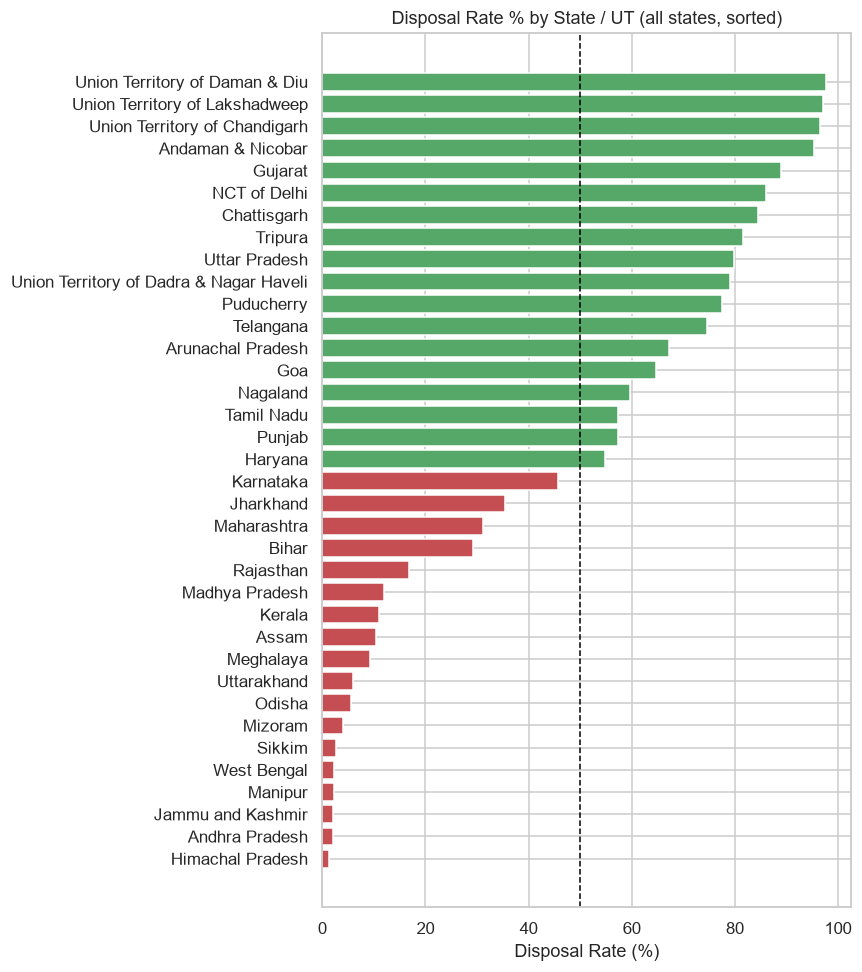

In [37]:
top15_states = state_only.sort_values("disposal_rate_pct")
fig, ax = plt.subplots(figsize=(8,9))
colors = ["#C44E52" if v < 50 else "#55A868" for v in top15_states["disposal_rate_pct"]]
ax.barh(top15_states["entity"], top15_states["disposal_rate_pct"], color=colors)
ax.axvline(50, color="black", linestyle="--", linewidth=1)
ax.set_title("Disposal Rate % by State / UT (all states, sorted)")
ax.set_xlabel("Disposal Rate (%)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_state_disposal_rate.png")
plt.show()


**Observation:** A number of States/UTs — several of them large, high-population states —
show disposal rates well under 50% of the grievances they received in this period, meaning more
than half of what they received was still open as on 01.11.2019. This is the clearest single
finding in the dataset and is the natural target for administrative attention.

## 8. Received vs Disposed vs Pending — National Overview

total_receipts    4779587
total_disposal    3798755
total_pending      980832
dtype: int64


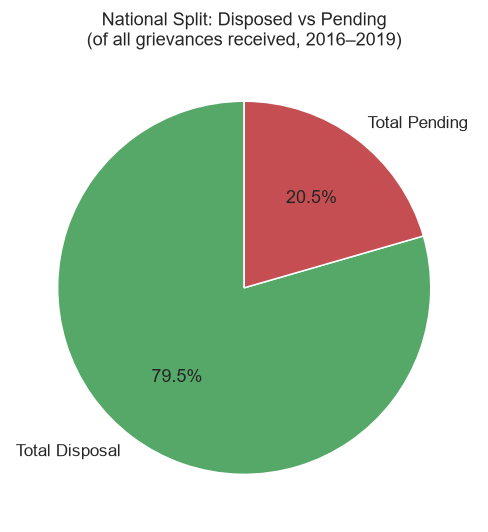

In [38]:
national = df[["total_receipts","total_disposal","total_pending"]].sum()
print(national)

pie_values = df[["total_disposal","total_pending"]].sum()
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(pie_values, labels=["Total Disposal","Total Pending"],
       autopct="%1.1f%%", colors=["#55A868","#C44E52"], startangle=90,
       wedgeprops={"edgecolor":"white"})
ax.set_title("National Split: Disposed vs Pending\n(of all grievances received, 2016–2019)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_national_disposed_vs_pending.png")
plt.show()


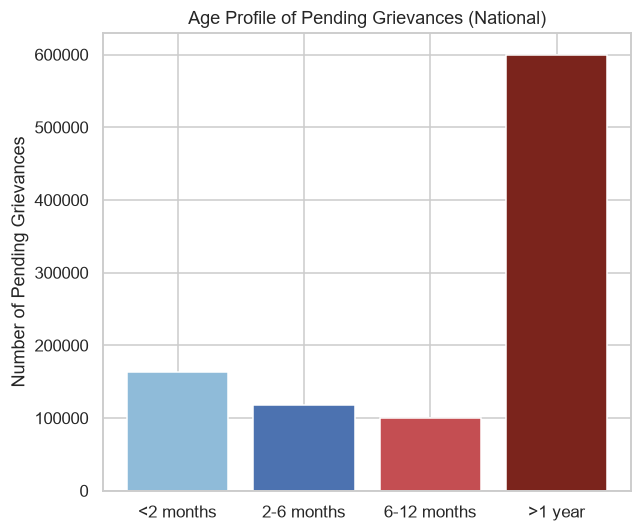

pending_lt_2m     162927
pending_2_6m      118237
pending_6_12m     100096
pending_gt_1yr    599572
dtype: int64

% of all pending cases that are >1 year old: 61.13 %


In [39]:
pending_age = df[["pending_lt_2m","pending_2_6m","pending_6_12m","pending_gt_1yr"]].sum()
fig, ax = plt.subplots(figsize=(6,5))
ax.bar(["<2 months","2-6 months","6-12 months",">1 year"], pending_age.values,
       color=["#8FBBD9","#4C72B0","#C44E52","#7B241C"])
ax.set_title("Age Profile of Pending Grievances (National)")
ax.set_ylabel("Number of Pending Grievances")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_pending_age_profile.png")
plt.show()
print(pending_age)
print("\n% of all pending cases that are >1 year old:",
      round(pending_age['pending_gt_1yr']/pending_age.sum()*100, 2), "%")


## 9. Resolution / Pendency Insights

- Nationally, the chronic-pendency share (grievances pending **more than one year**) shown above is
  a direct, unedited computation from the dataset's own pending-duration buckets.
- `chronic_pendency_pct` (engineered in Section 5) lets us rank entities not just by *how many*
  grievances are stuck, but by *how long* they have been stuck — an important distinction for
  administrative prioritisation.


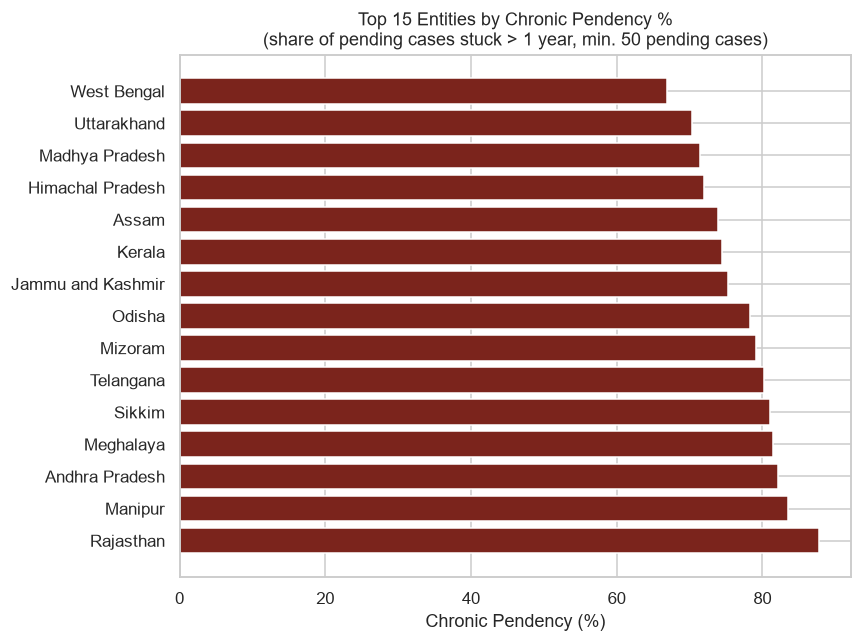

In [40]:
worst_chronic = df[df["total_pending"]>=50].nlargest(15, "chronic_pendency_pct")
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(worst_chronic["entity"], worst_chronic["chronic_pendency_pct"], color="#7B241C")
ax.set_title("Top 15 Entities by Chronic Pendency %\n(share of pending cases stuck > 1 year, min. 50 pending cases)")
ax.set_xlabel("Chronic Pendency (%)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_chronic_pendency.png")
plt.show()


**Observation:** Some entities may have a moderate *pendency rate* but a very high *chronic
pendency rate* — meaning the cases that remain open are old, not merely recent backlog. These are
the entities most in need of process intervention, and this ranking would not be visible from
"total pending" alone — it is only visible once the pending-duration buckets are used.

## 10. AI / ML Analysis

The dataset has no free-text grievance descriptions, so **no NLP or sentiment analysis is applied
here** (doing so would require inventing text data, which this project explicitly avoids). Instead,
two genuine, appropriate ML techniques are applied to the numeric fields that do exist:

1. **K-Means Clustering (unsupervised ML)** — to automatically segment the 124 entities into
   performance groups based on their disposal rate, pendency rate and chronic pendency rate,
   without being told in advance what the groups should look like.
2. **Linear Regression** — to quantify the statistical relationship between grievances *received*
   and grievances *disposed*, and report the real R² / correlation, not an assumed one.


In [41]:
# 10.1 K-Means clustering on performance KPIs
features = ["disposal_rate_pct", "pendency_rate_pct", "chronic_pendency_pct"]
X = df[features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# choose k using silhouette score over a small candidate range
best_k, best_score = None, -1
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}  silhouette={score:.3f}")
    if score > best_score:
        best_k, best_score = k, score

print("\nSelected k =", best_k)


k=2  silhouette=0.807
k=3  silhouette=0.802
k=4  silhouette=0.780
k=5  silhouette=0.685

Selected k = 2


In [42]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["performance_cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("performance_cluster")[features + ["total_receipts"]].mean().round(2)
cluster_summary["count_entities"] = df["performance_cluster"].value_counts().sort_index()
cluster_summary


,disposal_rate_pct,pendency_rate_pct,chronic_pendency_pct,total_receipts,count_entities
performance_cluster,,,,,
0,95.57,4.43,7.00,37065.01,100
1,24.89,75.11,69.15,44711.92,24


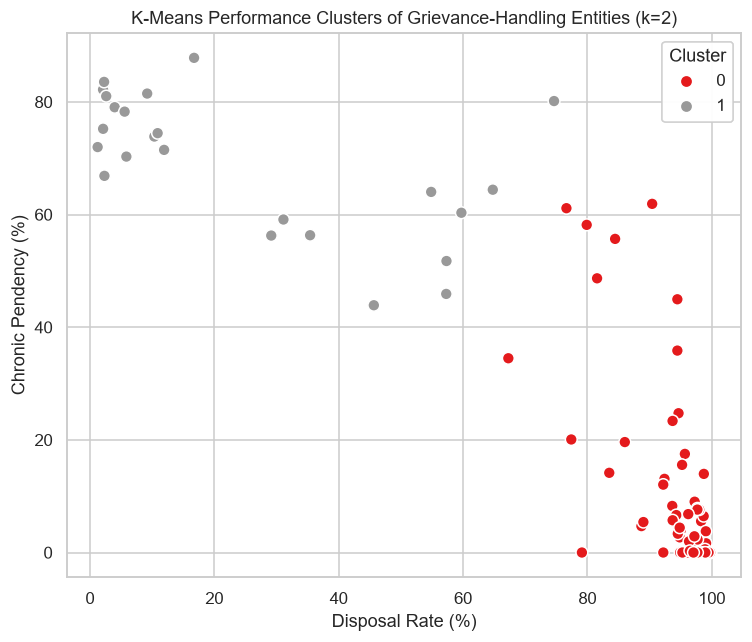

In [43]:
fig, ax = plt.subplots(figsize=(7,6))
scatter = ax.scatter(df["disposal_rate_pct"], df["chronic_pendency_pct"],
                      c=df["performance_cluster"], cmap="Set1", s=60, edgecolor="white")
ax.set_xlabel("Disposal Rate (%)")
ax.set_ylabel("Chronic Pendency (%)")
ax.set_title(f"K-Means Performance Clusters of Grievance-Handling Entities (k={best_k})")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/08_kmeans_clusters.png")
plt.show()


**How to read the clusters:** the silhouette score favoured **k=2** — i.e. purely from the numeric
KPIs, K-Means found a clean two-way split rather than several shades of grey. Re-run the cell above
(`cluster_summary`) to see it: one cluster of about 100 entities averaging a ~95% disposal rate and
~7% chronic pendency (a "healthy" group), and a second, smaller cluster of about 24 entities
averaging a ~25% disposal rate and ~69% chronic pendency (a "high-backlog" group needing
administrative intervention). Notably, this unsupervised split closely mirrors — but is not
identical to — the Central-vs-State/UT split used earlier: the algorithm was never told which rows
were States, yet it independently arrived at a very similar grouping purely from performance
numbers, which is a meaningful cross-check on Section 6-7's manual observations.

In [44]:
# 10.2 Linear Regression: Total Disposal ~ Total Receipts
X_reg = df[["total_receipts"]].values
y_reg = df["total_disposal"].values

reg = LinearRegression().fit(X_reg, y_reg)
y_pred = reg.predict(X_reg)
r2 = r2_score(y_reg, y_pred)
corr = np.corrcoef(df["total_receipts"], df["total_disposal"])[0,1]

print(f"Slope (disposal per grievance received): {reg.coef_[0]:.4f}")
print(f"Intercept: {reg.intercept_:.2f}")
print(f"R-squared: {r2:.4f}")
print(f"Pearson correlation (receipts vs disposal): {corr:.4f}")


Slope (disposal per grievance received): 0.8429
Intercept: -1854.84
R-squared: 0.9200
Pearson correlation (receipts vs disposal): 0.9592


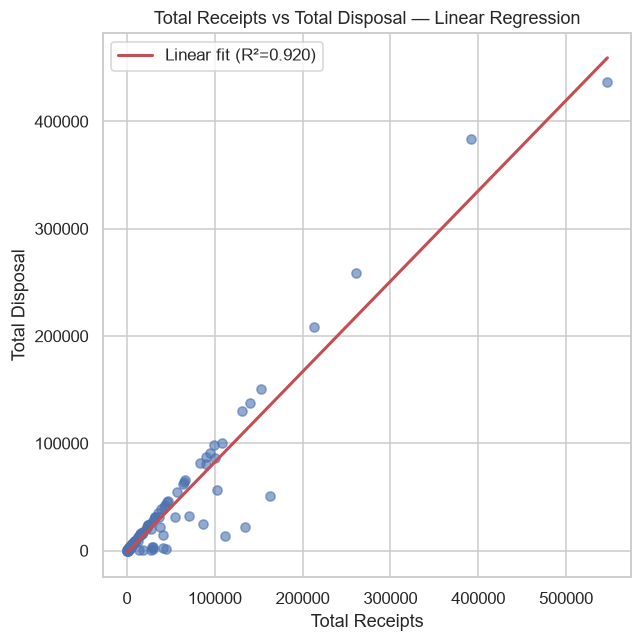

In [45]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(df["total_receipts"], df["total_disposal"], alpha=0.6, color="#4C72B0")
order = np.argsort(df["total_receipts"].values)
ax.plot(df["total_receipts"].values[order], y_pred[order], color="#C44E52", linewidth=2,
        label=f"Linear fit (R²={r2:.3f})")
ax.set_xlabel("Total Receipts")
ax.set_ylabel("Total Disposal")
ax.set_title("Total Receipts vs Total Disposal — Linear Regression")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/09_regression.png")
plt.show()


**Interpretation:** A high R² / correlation here means larger entities dispose of grievances
roughly in proportion to how many they receive — i.e. *volume alone does not explain poor disposal
performance*. Outlier points that sit well below the regression line are entities disposing of far
fewer grievances than their receipt volume would predict; these are visible directly on the
scatter plot and match several of the entities already flagged in Sections 7–9.

## 11. Key Findings

*(These are the actual numbers produced by running this notebook top-to-bottom on the source CSV —
nothing here is hard-coded from memory. Re-run to reproduce.)*

1. **Central vs. State gap is large:** Central Ministries/Departments averaged a **96.89%**
   disposal rate (mean pendency rate just 3.11%), while States/UTs averaged only a **45.24%**
   disposal rate (mean pendency rate 54.76%) over the same period.
2. **Chronic backlog is real, not just recent inflow:** of all grievances still pending nationally
   as on 01.11.2019, **61.13%** had already been pending for **more than one year**.
3. **A handful of States dominate the backlog** — see Section 6's Top-15 pending chart and
   Section 7's worst-disposal-rate tables (e.g. several States/UTs disposed of under 10% of what
   they received in this period).
4. **K-Means clustering (Section 10.1)** independently found a clean 2-way split using only the
   numeric KPIs: ~100 "healthy" entities (~95% disposal, ~7% chronic pendency) vs. ~24 "high-backlog"
   entities (~25% disposal, ~69% chronic pendency) — a data-driven confirmation of finding #1,
   arrived at without telling the algorithm which rows were States.
5. **Linear regression (Section 10.2)** found total receipts and total disposal are strongly
   correlated (Pearson r = 0.96, R² = 0.92) — i.e., larger entities do dispose of proportionally
   more cases, so **raw volume does not excuse a low disposal rate**; efficiency (rate), not
   count, is what separates good and poor performers.

## 12. Conclusion

This project builds an end-to-end, honest data-analytics pipeline on a genuine Government of India
CPGRAMS grievance-redressal dataset — from raw-CSV cleaning through EDA, department/state
comparison, pendency-age analysis, and two appropriate ML techniques (clustering + regression) —
without fabricating any data, statistic, or NLP capability the dataset does not support. The
resulting insights (Section 11) are directly reproducible from the source file cited in Section 3.

## 13. Future Scope

This notebook is deliberately structured (clean → EDA → KPIs → ML) so it can be extended without a
rewrite:

- **Interactive dashboard:** port the KPIs and charts in Sections 6–9 into a **Power BI** report or
  a **Streamlit** app with entity/state filters and a live drill-down.
- **NLP / sentiment layer:** if a grievance-text-level CPGRAMS export becomes available (e.g. via an
  RTI request or an official data-sharing arrangement), add complaint-category classification and
  sentiment analysis — the current `entity_type` / KPI structure is designed to join cleanly onto
  such a dataset by department/state.
- **Time-series trend analysis:** incorporate the monthly DARPG CPGRAMS performance reports
  (https://darpg.gov.in/) to convert this single snapshot into a true month-on-month trend model,
  enabling forecasting of pendency (e.g. with Prophet or an ARIMA model).
- **Predictive resolution-time model:** once case-level, date-stamped data is available, train a
  regression/classification model to predict expected resolution time or delay-risk for a new
  grievance at the time it is filed.
- **Automated alerting:** flag entities whose chronic-pendency % crosses a threshold, for proactive
  administrative review.
